**Name: Kaustubh Aswale**  
**Roll No: 69**  
**Assignment 2**

Create an “Academic performance” dataset ofstudents and perform the following operations using Python.
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or
inconsistencies, use any of the suitable techniques to deal with them.
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with
them.
3. Apply data transformations on at least one of the variables. The purpose of this transformation should be

one of the following reasons: to change the scale for better understanding of the variable, to convert a non-
linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal
distribution.

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# Possible categorical values
genders = ["male", "female"]
race_groups = ["group A", "group B", "group C", "group D", "group E"]
parent_education = [
    "some high school", "high school", "some college",
    "associate's degree", "bachelor's degree", "master's degree"
]
lunch_types = ["standard", "free/reduced"]
test_prep = ["none", "completed"]

# Generate 20 records
n = 20

data = {
    "gender": np.random.choice(genders, n),
    "race/ethnicity": np.random.choice(race_groups, n),
    "parental level of education": np.random.choice(parent_education, n),
    "lunch": np.random.choice(lunch_types, n),
    "test preparation course": np.random.choice(test_prep, n),
    "math score": np.random.randintypet(40, 100, n).astype(float),
    "reading score": np.random.randint(40, 100, n).as(float),
    "writing score": np.random.randint(40, 100, n).astype(float)
}

# Create DataFrame
df = pd.DataFrame(data)

# Introduce null values ONLY in numeric columns
numeric_cols = ["math score", "reading score", "writing score"]

for col in numeric_cols:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

# Display dataset
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,79.0,46.0,67.0
1,female,group B,some high school,free/reduced,none,60.0,48.0,46.0
2,male,group D,some college,standard,none,55.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,84.0,40.0,47.0
4,male,group D,some college,standard,completed,57.0,83.0,NaN
5,female,group E,bachelor's degree,free/reduced,completed,86.0,47.0,73.0
6,male,group A,some high school,standard,completed,92.0,63.0,72.0
7,male,group D,high school,standard,completed,63.0,50.0,87.0
8,male,group B,associate's degree,free/reduced,completed,65.0,90.0,94.0
9,female,group E,some high school,standard,completed,64.0,56.0,NaN


In [3]:
print("\nDataset Info:\n")
#Displaying the dataset information
df.describe()


Dataset Info:



,math score,reading score,writing score
count,18.000000,18.000000,18.000000
mean,75.111111,65.500000,68.000000
std,15.840710,19.321582,14.919391
min,54.000000,40.000000,40.000000
25%,63.250000,47.250000,61.500000
50%,73.500000,63.000000,72.500000
75%,85.500000,80.750000,75.500000
max,99.000000,98.000000,94.000000


In [4]:
print("shape and size of the data: ", df.shape, df.size)

shape and size of the data:  (20, 8) 160


In [5]:
#Checking for missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     2
reading score                  2
writing score                  2
dtype: int64


In [6]:
#Filling missing values with mean for numerical columns
for i in ["reading score", "writing score","math score"]:
    df[i] = df[i].fillna(df[i].mean())
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,79.0,46.0,67.0
1,female,group B,some high school,free/reduced,none,60.0,48.0,46.0
2,male,group D,some college,standard,none,55.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,84.0,40.0,47.0
4,male,group D,some college,standard,completed,57.0,83.0,68.0


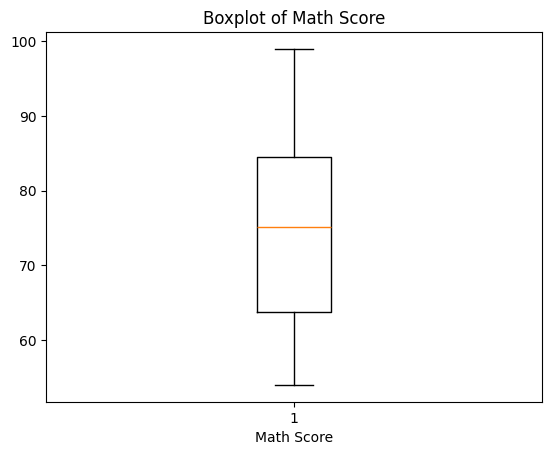

In [8]:
plt.figure()
plt.boxplot(df['math score'])
plt.title("Boxplot of Math Score")
plt.xlabel("Math Score")
plt.show()

In [9]:
#Calculating Q1, Q3, IQR, lower limit, and upper limit for 'math score'
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Q1: 63.75
Q3: 84.5
IQR: 20.75
Lower Limit: 32.625
Upper Limit: 115.625


In [10]:
outliers = df[(df['math score'] < lower_limit) | (df['math score'] > upper_limit)]
print("\nOutliers:\n", outliers)


Outliers:
 Empty DataFrame
Columns: [gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score]
Index: []


In [11]:
#Removing outliers from the dataset
df_clean = df[(df['math score'] >= lower_limit) & (df['math score'] <= upper_limit)]

print("\nAfter Removing Outliers:\n", df_clean.shape)


After Removing Outliers:
 (20, 8)


In [12]:
df_clean = df[(df['math score'] >= lower_limit) & 
              (df['math score'] <= upper_limit)].copy()

In [13]:
#Scaling the 'math score' column using Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_clean['math_scaled'] = scaler.fit_transform(df_clean[['math score']])

In [14]:
df_clean['math_zscore'] = (df_clean['math score'] - df_clean['math score'].mean()) / df_clean['math score'].std()

In [15]:
print("\nSkewness:\n", df_clean[['math score', 'reading score', 'writing score']].skew())


Skewness:
 math score       0.273617
reading score    0.351952
writing score   -0.412976
dtype: float64


In [16]:
df_clean['math_log'] = np.log(df_clean['math score'])

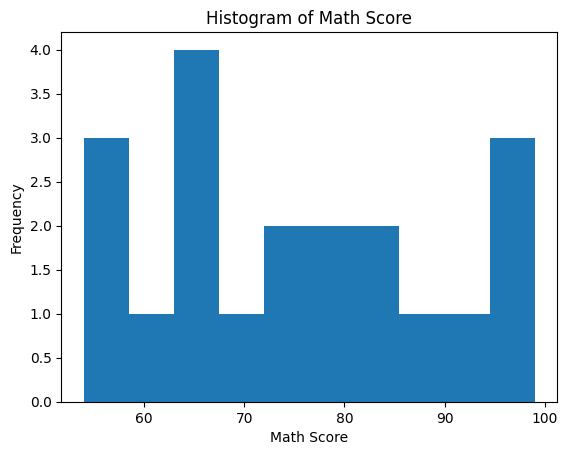

In [17]:
plt.figure()
plt.hist(df_clean['math score'], bins=10)
plt.title("Histogram of Math Score")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

In [18]:
print("\nStatistical Summary:\n", df_clean.describe())


Statistical Summary:
        math score  reading score  writing score  math_scaled   math_zscore  \
count   20.000000      20.000000      20.000000    20.000000  2.000000e+01   
mean    75.111111      65.500000      68.000000     0.469136 -1.887379e-16   
std     14.983812      18.276387      14.112331     0.332974  1.000000e+00   
min     54.000000      40.000000      40.000000     0.000000 -1.408928e+00   
25%     63.750000      47.750000      62.500000     0.216667 -7.582257e-01   
50%     75.111111      64.250000      70.000000     0.469136  0.000000e+00   
75%     84.500000      80.250000      74.500000     0.677778  6.266022e-01   
max     99.000000      98.000000      94.000000     1.000000  1.594313e+00   

        math_log  
count  20.000000  
mean    4.300052  
std     0.199762  
min     3.988984  
25%     4.154946  
50%     4.318968  
75%     4.436699  
max     4.595120  


In [19]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,79.000000,46.0,67.0
1,female,group B,some high school,free/reduced,none,60.000000,48.0,46.0
2,male,group D,some college,standard,none,55.000000,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,84.000000,40.0,47.0
4,male,group D,some college,standard,completed,57.000000,83.0,68.0
5,female,group E,bachelor's degree,free/reduced,completed,86.000000,47.0,73.0
6,male,group A,some high school,standard,completed,92.000000,63.0,72.0
7,male,group D,high school,standard,completed,63.000000,50.0,87.0
8,male,group B,associate's degree,free/reduced,completed,65.000000,90.0,94.0
9,female,group E,some high school,standard,completed,64.000000,56.0,68.0
